https://github.com/diegomel07/Proyecto-Optimizacion

<div style="background: linear-gradient(135deg, #1a237e 0%, #283593 60%, #3949ab 100%); padding: 40px 36px 32px 36px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; font-weight: 700; margin: 0 0 8px 0; letter-spacing: 0.5px;">Problema 6, Localización de Instalaciones con Capacidad</h1>
  <h2 style="color: #90caf9; font-size: 1.2em; font-weight: 400; margin: 0 0 18px 0;">Capacitated Facility Location Problem (CFLP)</h2>
</div>

## 1. Introducción y Contexto del Problema <a id='1-introduccion'></a>

El Problema de Localización de Instalaciones con Capacidad (CFLP, por sus siglas en inglés) es un problema clásico de optimización combinatoria con amplia aplicación en logística, cadenas de suministro, redes de distribución y planificación estratégica.

El problema busca responder la pregunta: ¿Cuáles instalaciones (bodegas, plantas, centros de distribución) deben abrirse y cómo deben asignarse los clientes a ellas, minimizando los costos totales?*´

### Componentes del costo
El CFLP considera dos tipos de costos:
- **Costo fijo de apertura** $c_i$: incurrido al decidir abrir la instalación $i$, independientemente de cuántos clientes atienda.
- **Costo variable de asignación** $g_{ij}$: costo de producción y transporte para atender la demanda del cliente $j$ desde la instalación $i$.

La instancia utilizada (`cap41.txt`) proviene de la OR-Library, un repositorio estándar de benchmarks de investigación de operaciones. Contiene 16 instalaciones potenciales y 50 clientes. (Sobolev Institute of Mathematics, 2024)

---
## 2. Formulación Matemática <a id='2-formulacion'></a>

### Conjuntos e Índices

- $I = \{1,2,\ldots,m\}$: Conjunto de instalaciones potenciales.
- $J = \{1,2,\ldots,n\}$: Conjunto de clientes.
- $i \in I$: Índice de instalación.
- $j \in J$: Índice de cliente.

### Parámetros

- $c_i \geq 0$: Costo fijo de abrir la instalación $i$
- $g_{ij} \geq 0$: Costo de asignar (producción + transporte) la demanda del cliente $j$ a la instalación $i$
- $V_i > 0$: Capacidad máxima de la instalación $i$
- $p_j > 0$: Demanda del cliente $j$

### Variables de Decisión

Variable binaria de apertura:
$$
y_i = \begin{cases}
  1 & \text{si la instalación } i \text{ es abierta} \\
  0 & \text{en caso contrario}
\end{cases}
\qquad i \in I
$$

Variable continua de asignación (relajación LP del problema entero):
$$
x_{ij} \in [0, 1] \qquad i \in I,\; j \in J
$$

donde $x_{ij}$ representa la fracción de la demanda del cliente $j$ atendida por la instalación $i$.


### Modelo de Programación Lineal Entera Mixta (PLIM)

**Función Objetivo — Minimización del costo total:**

$$
\min \quad z = \underbrace{\sum_{i \in I} c_i \, y_i}_{\text{costos fijos}} + \underbrace{\sum_{i \in I} \sum_{j \in J} g_{ij} \, x_{ij}}_{\text{costos variables}}
$$

**Sujeto a:**

**(R1) Restricción de satisfacción de demanda**: cada cliente debe recibir el 100% de su demanda:
$$
\sum_{i \in I} x_{ij} = 1, \qquad \forall\, j \in J
$$

**(R2) Restricción de capacidad**: la carga total asignada a una instalación no puede exceder su capacidad; además, si la instalación está cerrada ($y_i = 0$), no puede atender a nadie:
$$
\sum_{j \in J} p_j \, x_{ij} \leq V_i \, y_i, \qquad \forall\, i \in I
$$

**(R3) Dominio de las variables:**
$$
x_{ij} \in [0, 1], \qquad \forall\, i \in I,\; j \in J
$$
$$
y_i \in \{0, 1\}, \qquad \forall\, i \in I
$$

### Observaciones sobre la formulación

- El modelo tiene $m \cdot n$ variables continuas y $m$ variables binarias, con $n + m$ restricciones funcionales. Para la instancia `cap41`: **800 variables continuas + 16 binarias, 66 restricciones**.
- El problema es **NP-difícil** en su forma general; sin embargo, la relajación LP es frecuentemente muy ajustada (gap pequeño). (duda)

---
## 3. Implementación del Modelo <a id='3-implementacion'></a>

### 3.1 Instalación de dependencias

In [62]:
%pip install gurobipy --quiet

### 3.2 Lectura de datos

In [63]:
def read_cflp(filename):
    """
    Lee una instancia CFLP en formato OR-Library.

    Formato del archivo:
        Línea 1: m n  (instalaciones, clientes)
        Siguientes m líneas: capacity_i  fixed_cost_i
        Siguientes n bloques: demand_j  cost_j_1 cost_j_2 ... cost_j_m

    Retorna:
        m           -- número de instalaciones potenciales
        n           -- número de clientes
        capacity    -- lista de capacidades V_i
        fixed_cost  -- lista de costos fijos c_i
        demand      -- lista de demandas p_j
        cost        -- matriz cost[j][i] = g_{ij}
    """
    with open(filename, "r") as f:
        data = f.read().split()

    idx = 0
    m = int(data[idx]); idx += 1
    n = int(data[idx]); idx += 1

    capacity   = []
    fixed_cost = []
    for i in range(m):
        capacity.append(float(data[idx]));   idx += 1
        fixed_cost.append(float(data[idx])); idx += 1

    demand = []
    cost   = []
    for j in range(n):
        demand.append(float(data[idx])); idx += 1
        row = [float(data[idx + i]) for i in range(m)]
        idx += m
        cost.append(row)

    return m, n, capacity, fixed_cost, demand, cost


m, n, capacity, fixed_cost, demand, cost = read_cflp("cap41.txt")

print("=" * 50)
print("  Resumen de la instancia cap41")
print("=" * 50)
print(f"  Instalaciones potenciales (m): {m}")
print(f"  Clientes              (n):     {n}")
print(f"  Capacidad mín / máx:           {min(capacity):.0f} / {max(capacity):.0f}")
print(f"  Costo fijo mín / máx:          {min(fixed_cost):.0f} / {max(fixed_cost):.0f}")
print(f"  Demanda mín / máx:             {min(demand):.0f} / {max(demand):.0f}")
print(f"  Demanda total:                 {sum(demand):.0f}")
print(f"  Capacidad total disponible:    {sum(capacity):.0f}")
print(f"  Holgura de capacidad:          {sum(capacity)/sum(demand):.2f}x la demanda total")
print("=" * 50)

  Resumen de la instancia cap41
  Instalaciones potenciales (m): 16
  Clientes              (n):     50
  Capacidad mín / máx:           5000 / 5000
  Costo fijo mín / máx:          0 / 7500
  Demanda mín / máx:             31 / 12912
  Demanda total:                 58268
  Capacidad total disponible:    80000
  Holgura de capacidad:          1.37x la demanda total


### 3.3 Construcción y resolución del modelo Gurobi

In [64]:
from gurobipy import Model, GRB, quicksum

# --------------------------------------------------------
# Construcción del modelo
# --------------------------------------------------------
model = Model("CFLP_cap41")

# --- Variables de decisión ---
# x[i,j]: fracción de demanda del cliente j atendida por instalación i
x = model.addVars(m, n, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="x")

# y[i]: 1 si la instalación i es abierta, 0 si no
y = model.addVars(m, vtype=GRB.BINARY, name="y")

# --- Función objetivo ---
model.setObjective(
    quicksum(fixed_cost[i] * y[i] for i in range(m))
    + quicksum(cost[j][i] * x[i, j] for i in range(m) for j in range(n)),
    GRB.MINIMIZE
)

# --- Restricciones ---
# (R1) Satisfacción de demanda: cada cliente debe ser atendido al 100%
dem_constrs = model.addConstrs(
    (quicksum(x[i, j] for i in range(m)) == 1 for j in range(n)),
    name="demanda"
)

# (R2) Capacidad de cada instalación
cap_constrs = model.addConstrs(
    (quicksum(demand[j] * x[i, j] for j in range(n)) <= capacity[i] * y[i]
     for i in range(m)),
    name="capacidad"
)


model.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 66 rows, 816 columns and 1616 nonzeros (Min)
Model fingerprint: 0xfe89a70e
Model has 814 linear objective coefficients
Variable types: 800 continuous, 16 integer (16 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [5e+02, 1e+06]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 0 rows and 1 columns
Presolve time: 0.01s
Presolved: 66 rows, 815 columns, 1615 nonzeros
Variable types: 800 continuous, 15 integer (15 binary)
Found heuristic solution: objective 1050749.6250

Root relaxation: objective 1.018152e+06, 32 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | 

---
## 4. Resultados de la Optimización <a id='4-resultados'></a>

In [65]:
if model.Status != GRB.OPTIMAL:
    print(f"El modelo no alcanzó optimalidad. Estado: {model.Status}")
else:
    # Costo óptimo total
    z_opt = model.ObjVal
    costo_fijo_total    = sum(fixed_cost[i] * y[i].X for i in range(m))
    costo_variable_total = sum(cost[j][i] * x[i, j].X for i in range(m) for j in range(n))

    print("=" * 60)
    print("  SOLUCIÓN ÓPTIMA")
    print("=" * 60)
    print(f"  Costo total óptimo (z*):          {z_opt:>14,.2f}")
    print(f"  └─ Costos fijos de apertura:      {costo_fijo_total:>14,.2f}  ({100*costo_fijo_total/z_opt:.1f}%)")
    print(f"  └─ Costos variables de asignación:{costo_variable_total:>14,.2f}  ({100*costo_variable_total/z_opt:.1f}%)")
    print("=" * 60)

    # Instalaciones abiertas
    abiertas = [i for i in range(m) if y[i].X > 0.5]
    print(f"\n  Instalaciones abiertas: {len(abiertas)} de {m}")
    print(f"  IDs: {[i+1 for i in abiertas]}\n")

    # Utilización de instalaciones abiertas
    print("-" * 60)
    print(f"  {'Instalación':^12} {'Carga':^12} {'Capacidad':^12} {'Utilización':^12}")
    print("-" * 60)
    for i in abiertas:
        carga = sum(demand[j] * x[i, j].X for j in range(n))
        util  = 100 * carga / capacity[i]
        print(f"  {i+1:^12} {carga:^12.1f} {capacity[i]:^12.0f} {util:^11.1f}%")
    print("-" * 60)

    # Asignación de clientes
    print("\n  Asignación de clientes (primeros 10):")
    print("-" * 60)
    for j in range(min(10, n)):
        asig = [(i+1, round(x[i,j].X, 4)) for i in range(m) if x[i,j].X > 1e-6]
        print(f"  Cliente {j+1:>2} (demanda={demand[j]:>6.0f}): {asig}")
    if n > 10:
        print(f"  ... ({n-10} clientes adicionales omitidos)")
    print("-" * 60)

  SOLUCIÓN ÓPTIMA
  Costo total óptimo (z*):            1,040,444.38
  └─ Costos fijos de apertura:           90,000.00  (8.7%)
  └─ Costos variables de asignación:    950,444.38  (91.3%)

  Instalaciones abiertas: 13 de 16
  IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14]

------------------------------------------------------------
  Instalación     Carga      Capacidad   Utilización 
------------------------------------------------------------
       1          4903.0        5000        98.1    %
       2          5000.0        5000        100.0   %
       3          5000.0        5000        100.0   %
       4          5000.0        5000        100.0   %
       5          5000.0        5000        100.0   %
       6          5000.0        5000        100.0   %
       7          2166.0        5000        43.3    %
       8          4350.0        5000        87.0    %
       9          5000.0        5000        100.0   %
       11         5000.0        5000        100.0   %
       1

---
## 5. Análisis de Sensibilidad <a id='5-sensibilidad'></a>

El análisis de sensibilidad permite determinar **qué tan robusta es la solución óptima** frente a cambios en los parámetros del problema. Se realizan tres experimentos:

| Experimento | Parámetro perturbado | Objetivo |
|---|---|---|
| S1 | Costos fijos $c_i$ | Evaluar umbral de apertura/cierre de instalaciones |
| S2 | Capacidades $V_i$ | Medir impacto de restricciones de capacidad |
| S3 | Demandas $p_j$ | Evaluar resiliencia ante cambios de demanda |

### 5.1 Precios sombra y rangos de optimalidad

In [66]:
# -------------------------------------------------------------------
# NOTA: Gurobi no calcula precios sombra (atributo .Pi)
# para modelos MIP porque el simplex no se ejecuta en el nodo raíz
# con variables enteras fijadas.
#
# -------------------------------------------------------------------

from gurobipy import Model, GRB, quicksum

if model.Status == GRB.OPTIMAL:

    # Valores óptimos de y obtenidos del MIP
    y_opt = {i: 1 if y[i].X > 0.5 else 0 for i in range(m)}

    # ── Construir LP con y fijas ─────────────────────────────────────
    lp = Model("CFLP_LP_dual")
    lp.Params.OutputFlag = 0

    xLP = lp.addVars(m, n, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="x")

    lp.setObjective(
        quicksum(cost[j][i] * xLP[i, j] for i in range(m) for j in range(n)),
        GRB.MINIMIZE
    )

    # (R1) Satisfacción de demanda
    dem_lp = lp.addConstrs(
        (quicksum(xLP[i, j] for i in range(m)) == 1 for j in range(n)),
        name="demanda"
    )

    # (R2) Capacidad — y_opt[i] ya es un escalar conocido
    cap_lp = lp.addConstrs(
        (quicksum(demand[j] * xLP[i, j] for j in range(n)) <= capacity[i] * y_opt[i]
         for i in range(m)),
        name="capacidad"
    )

    lp.optimize()

    # ── Precios sombra ───────────────────────────────────────────────
    if lp.Status == GRB.OPTIMAL:

        print("=" * 70)
        print("  PRECIOS SOMBRA — Restricciones de Demanda (R1)")
        print("  π_j = costo marginal de incrementar en 1 unidad la demanda del cliente j")
        print("=" * 70)
        print(f"  {'Cliente':^10} {'Demanda':^10} {'π_j':^14} {'Nivel'}")
        print("-" * 70)

        pi_dem = [lp.getConstrByName(f"demanda[{j}]").Pi for j in range(n)]
        umbral = sorted([abs(p) for p in pi_dem], reverse=True)[int(0.2 * n)]  # top 20%

        for j in range(n):
            pi = pi_dem[j]
            nivel = "▲ Alto" if abs(pi) >= umbral else "  Normal"
            print(f"  {j+1:^10} {demand[j]:^10.0f} {pi:^14.2f} {nivel}")

        print()
        print("=" * 70)
        print("  PRECIOS SOMBRA — Restricciones de Capacidad (R2)")
        print("  μ_i = ahorro en costo si se amplia en 1 unidad la capacidad de la instalación i")
        print("=" * 70)
        print(f"  {'Instalación':^13} {'Estado':^9} {'μ_i':^14} {'Holgura':^10} {'Diagnóstico'}")
        print("-" * 70)

        for i in range(m):
            constr = lp.getConstrByName(f"capacidad[{i}]")
            pi    = constr.Pi
            slack = constr.Slack
            estado = "Abierta" if y_opt[i] == 1 else "Cerrada"
            if y_opt[i] == 0:
                diag = "Inactiva (cerrada)"
            elif abs(pi) > 1e-6:
                diag = f"Saturada — ampliar cap. ahorra {abs(pi):.2f}/unidad"
            else:
                diag = f"Con holgura ({slack:.1f} uds disponibles)"
            print(f"  {i+1:^13} {estado:^9} {pi:^14.4f} {slack:^10.1f} {diag}")

        print()
        print(f"  Instalaciones saturadas (μ_i < 0): "
              f"{sum(1 for i in range(m) if lp.getConstrByName(f'capacidad[{i}]').Pi < -1e-6)} de {sum(y_opt.values())} abiertas")
    else:
        print("La LP auxiliar no alcanzó optimalidad. Revisar datos.")

  PRECIOS SOMBRA — Restricciones de Demanda (R1)
  π_j = costo marginal de incrementar en 1 unidad la demanda del cliente j
   Cliente    Demanda        π_j       Nivel
----------------------------------------------------------------------
      1         146        3847.10       Normal
      2          87        1808.51       Normal
      3         672        4914.00       Normal
      4         1337       32372.11      Normal
      5          31         955.58       Normal
      6         559        6421.51       Normal
      7         2370       54065.63    ▲ Alto
      8         1089       20296.24      Normal
      9          33        1211.92       Normal
      10         32         546.40       Normal
      11        5495       70679.44    ▲ Alto
      12        904        8734.90       Normal
      13        1466       20908.83      Normal
      14        143        1953.74       Normal
      15        615        7310.81       Normal
      16        564        8135.70       Nor

### 5.2 Experimento S1 — Variación de costos fijos

In [67]:
from gurobipy import Model, GRB, quicksum

def solve_cflp(m, n, capacity, fixed_cost, demand, cost, verbose=False):
    """Resuelve el CFLP y retorna (costo_total, instalaciones_abiertas)."""
    mdl = Model("CFLP")
    mdl.Params.OutputFlag = 0  # silencioso
    x = mdl.addVars(m, n, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="x")
    y = mdl.addVars(m, vtype=GRB.BINARY, name="y")
    mdl.setObjective(
        quicksum(fixed_cost[i] * y[i] for i in range(m))
        + quicksum(cost[j][i] * x[i, j] for i in range(m) for j in range(n)),
        GRB.MINIMIZE
    )
    mdl.addConstrs((quicksum(x[i,j] for i in range(m)) == 1 for j in range(n)), name="dem")
    mdl.addConstrs(
        (quicksum(demand[j]*x[i,j] for j in range(n)) <= capacity[i]*y[i] for i in range(m)),
        name="cap"
    )
    mdl.optimize()
    if mdl.Status == GRB.OPTIMAL:
        abiertas = sum(1 for i in range(m) if y[i].X > 0.5)
        return mdl.ObjVal, abiertas
    return None, None


# S1: Escalar costos fijos en ±50%
print("=" * 65)
print("  S1: VARIACIÓN DE COSTOS FIJOS (escalados uniformemente)")
print("=" * 65)
print(f"  {'Factor':^10} {'Costo total':^15} {'Δ vs base':^12} {'Instalaciones abiertas':^22}")
print("-" * 65)

z_base, inst_base = solve_cflp(m, n, capacity, fixed_cost, demand, cost)
factores = [0.50, 0.75, 1.00, 1.25, 1.50, 2.00]

for f in factores:
    fc_mod = [c * f for c in fixed_cost]
    z, inst = solve_cflp(m, n, capacity, fc_mod, demand, cost)
    delta = f"{'+'if z-z_base>=0 else ''}{100*(z-z_base)/z_base:.1f}%" if z else "N/A"
    base_tag = "  ◄ BASE" if f == 1.0 else ""
    print(f"  {f:^10.2f} {z:^15,.2f} {delta:^12} {inst:^22}{base_tag}")
print("-" * 65)
print("  Interpretación: a mayor costo fijo -> tiende a abrir menos instalaciones")

  S1: VARIACIÓN DE COSTOS FIJOS (escalados uniformemente)
    Factor     Costo total    Δ vs base   Instalaciones abiertas
-----------------------------------------------------------------
     0.50      994,499.62       -4.4%               16          
     0.75     1,017,944.38      -2.2%               13          
     1.00     1,040,444.38      +0.0%               13            ◄ BASE
     1.25     1,062,944.38      +2.2%               13          
     1.50     1,084,250.45      +4.2%               12          
     2.00     1,125,500.45      +8.2%               12          
-----------------------------------------------------------------
  Interpretación: a mayor costo fijo -> tiende a abrir menos instalaciones


### 5.3 Experimento S2 — Variación de capacidades

In [68]:
print("=" * 65)
print("  S2: VARIACIÓN DE CAPACIDADES (escaladas uniformemente)")
print("=" * 65)
print(f"  {'Factor':^10} {'Costo total':^15} {'Δ vs base':^12} {'Instalaciones abiertas':^22}")
print("-" * 65)

factores_cap = [0.70, 0.85, 1.00, 1.15, 1.30, 1.50]

for f in factores_cap:
    cap_mod = [c * f for c in capacity]
    z, inst = solve_cflp(m, n, cap_mod, fixed_cost, demand, cost)
    if z is None:
        print(f"  {f:^10.2f} {'INFACTIBLE':^15} {'---':^12} {'---':^22}")
    else:
        delta = f"{'+'if z-z_base>=0 else ''}{100*(z-z_base)/z_base:.1f}%"
        base_tag = "  ◄ BASE" if f == 1.0 else ""
        print(f"  {f:^10.2f} {z:^15,.2f} {delta:^12} {inst:^22}{base_tag}")
print("-" * 65)
print("  Interpretación: reducir capacidad puede requerir abrir más instalaciones")
print("  o incluso volver el problema infactible si la capacidad total < demanda total.")

  S2: VARIACIÓN DE CAPACIDADES (escaladas uniformemente)
    Factor     Costo total    Δ vs base   Instalaciones abiertas
-----------------------------------------------------------------
     0.70      INFACTIBLE        ---               ---          
     0.85     1,163,498.70      +11.8%              15          
     1.00     1,040,444.38      +0.0%               13            ◄ BASE
     1.15      987,869.73       -5.1%               12          
     1.30      967,123.05       -7.0%               12          
     1.50      955,195.69       -8.2%               11          
-----------------------------------------------------------------
  Interpretación: reducir capacidad puede requerir abrir más instalaciones
  o incluso volver el problema infactible si la capacidad total < demanda total.


### 5.4 Experimento S3 — Variación de demanda

In [69]:
print("=" * 65)
print("  S3: VARIACIÓN DE DEMANDA (escalada uniformemente)")
print("=" * 65)
print(f"  {'Factor':^10} {'Costo total':^15} {'Δ vs base':^12} {'Instalaciones abiertas':^22}")
print("-" * 65)

factores_dem = [0.70, 0.85, 1.00, 1.10, 1.20, 1.30]

for f in factores_dem:
    dem_mod = [d * f for d in demand]
    z, inst = solve_cflp(m, n, capacity, fixed_cost, dem_mod, cost)
    if z is None:
        print(f"  {f:^10.2f} {'INFACTIBLE':^15} {'---':^12} {'---':^22}")
    else:
        delta = f"{'+'if z-z_base>=0 else ''}{100*(z-z_base)/z_base:.1f}%"
        base_tag = "  ◄ BASE" if f == 1.0 else ""
        print(f"  {f:^10.2f} {z:^15,.2f} {delta:^12} {inst:^22}{base_tag}")
print("-" * 65)
print("  Interpretación: el crecimiento de demanda aumenta presión sobre la capacidad")
print("  y puede forzar la apertura de instalaciones adicionales.")

  S3: VARIACIÓN DE DEMANDA (escalada uniformemente)
    Factor     Costo total    Δ vs base   Instalaciones abiertas
-----------------------------------------------------------------
     0.70      959,349.02       -7.8%               12          
     0.85      981,441.76       -5.7%               12          
     1.00     1,040,444.38      +0.0%               13            ◄ BASE
     1.10     1,097,330.64      +5.5%               15          
     1.20     1,183,964.32      +13.8%              15          
     1.30     1,283,121.84      +23.3%              16          
-----------------------------------------------------------------
  Interpretación: el crecimiento de demanda aumenta presión sobre la capacidad
  y puede forzar la apertura de instalaciones adicionales.


---
## 6. Análisis de Resultados e Implicaciones <a id='6-analisis'></a>

### 6.1 Estructura de la solución óptima

La solución óptima del modelo para la instancia `cap41` revela las siguientes características estructurales:

In [70]:
if model.Status == GRB.OPTIMAL:
    abiertas = [i for i in range(m) if y[i].X > 0.5]

    # Carga y utilización de cada instalación abierta
    cargas = {i: sum(demand[j] * x[i, j].X for j in range(n)) for i in abiertas}
    utils  = {i: 100 * cargas[i] / capacity[i] for i in abiertas}

    # Clientes con asignación fraccionada (múltiples fuentes)
    clientes_split = [
        j for j in range(n)
        if sum(1 for i in range(m) if x[i,j].X > 1e-6) > 1
    ]

    print("=" * 65)
    print("  RESUMEN ANALÍTICO DE LA SOLUCIÓN")
    print("=" * 65)
    print(f"  Instalaciones abiertas:           {len(abiertas)} / {m}")
    print(f"  Tasa de apertura:                 {100*len(abiertas)/m:.1f}%")
    print(f"  Utilización promedio:             {sum(utils.values())/len(utils):.1f}%")
    print(f"  Utilización mínima / máxima:      {min(utils.values()):.1f}% / {max(utils.values()):.1f}%")
    print(f"  Clientes con asignación múltiple: {len(clientes_split)} / {n}  "
          f"({'split delivery permitido' if clientes_split else 'ninguno'})")
    print(f"  Capacidad total utilizada:        {sum(cargas.values()):.0f} / {sum(capacity[i] for i in abiertas):.0f}")
    print(f"  Eficiencia global de capacidad:   {100*sum(cargas.values())/sum(capacity[i] for i in abiertas):.1f}%")
    print("=" * 65)

    # Instalación más y menos cargada
    i_max = max(utils, key=utils.get)
    i_min = min(utils, key=utils.get)
    print(f"\n  ▲ Instalación más cargada:   #{i_max+1} al {utils[i_max]:.1f}% de su capacidad")
    print(f"  ▼ Instalación menos cargada: #{i_min+1} al {utils[i_min]:.1f}% de su capacidad")

  RESUMEN ANALÍTICO DE LA SOLUCIÓN
  Instalaciones abiertas:           13 / 16
  Tasa de apertura:                 81.2%
  Utilización promedio:             89.6%
  Utilización mínima / máxima:      37.0% / 100.0%
  Clientes con asignación múltiple: 6 / 50  (split delivery permitido)
  Capacidad total utilizada:        58268 / 65000
  Eficiencia global de capacidad:   89.6%

  ▲ Instalación más cargada:   #2 al 100.0% de su capacidad
  ▼ Instalación menos cargada: #14 al 37.0% de su capacidad


### 6.2 Implicaciones prácticas de la solución

**6.2.1 Concentración vs. distribución de instalaciones**

El número de instalaciones abiertas en la solución óptima refleja el **balance costo fijo–costo variable**: abrir pocas instalaciones reduce costos fijos pero incrementa los costos de transporte (los clientes quedan lejos), mientras que abrir muchas reduce los costos variables pero dispara los costos fijos. La solución óptima logra el equilibrio entre ambos.

**6.2.2 Utilización de capacidad**

Instalaciones con utilización muy alta (>90%) son **cuellos de botella potenciales**: cualquier incremento de demanda o falla operativa puede hacer inviable la asignación actual. Se recomienda:
- Mantener un inventario de seguridad o capacidad de reserva.
- Monitorear instalaciones con utilización baja (posibles candidatas a cierre en reestructuraciones).

**6.2.3 Asignación fraccionada de clientes**

La presencia de clientes atendidos por múltiples instalaciones (split delivery) puede indicar que la capacidad está muy ajustada en algunas instalaciones. En la práctica, suele preferirse la asignación única por simplicidad operativa, lo que podría lograrse añadiendo la restricción $x_{ij} \in \{0,1\}$ (a costo de mayor tiempo de cómputo).

**6.2.4 Resiliencia frente a variaciones (del análisis de sensibilidad)**

| Hallazgo | Implicación |
|---|---|
| Costo total crece más lentamente que los costos fijos | La solución reemplaza instalaciones costosas con asignaciones variables más largas |
| Reducción de capacidad <85% puede generar infactibilidad | Existe un límite mínimo de capacidad sistémica que no debe violarse |
| Aumento de demanda >20% requiere más instalaciones | La red actual no absorbe crecimientos importantes sin inversión adicional |
| Precios sombra positivos en restricciones activas | Expandir la capacidad de instalaciones saturadas tiene un retorno económico positivo y cuantificable |

**6.2.5 Valor de la información (análisis de los precios sombra)**

Los **precios sombra de las restricciones de demanda** ($\pi_j$) indican el costo marginal de atender una unidad adicional de demanda del cliente $j$. Clientes con $|\pi_j|$ elevado son los más costosos de servir, ya sea porque están geográficamente alejados o porque su instalación asignada opera al límite de capacidad. Estos clientes son candidatos prioritarios para:
- Negociar reducciones de demanda o reubicación.
- Apertura de una nueva instalación cercana en etapas futuras.

---
## 7. Conclusiones <a id='7-conclusiones'></a>


### Hallazgos principales

1. **Formulación:** El CFLP se formula como un PLIM con variables binarias de apertura ($y_i$) y variables continuas de asignación ($x_{ij}$).

2. **Solución óptima:** Gurobi encontró la solución óptima en tiempo reducido, confirmando la efectividad de la relajación LP continua para esta instancia.

3. **Sensibilidad:**
   - La solución es **relativamente robusta** ante variaciones moderadas de costos fijos (±25%).
   - La **capacidad es el parámetro más crítico**: reducciones significativas pueden hacer el problema infactible.
   - Los **precios sombra** permiten cuantificar el valor económico de inversiones en capacidad adicional.

4. **Implicaciones estratégicas:** La red óptima concentra operaciones en un subconjunto de instalaciones con alta utilización, priorizando el ahorro en costos fijos. Esto implica menor resiliencia operativa, trade-off que debe considerarse en decisiones reales.


<div style="background-color:#e8f5e9; border-left: 5px solid #2e7d32; padding: 14px 18px; border-radius: 6px; margin-top: 16px;">


---

## Problema 7 Modelo (Set Covering)

En el problema de set covering se busca minimizar el costo total asociado a la selección de un subconjunto de columnas que cubren todos los requisitos.

### Importancia y aplicaciones

El problema de set covering (SCP) es usado en muchos sectores, principalmente usado para la gestión de operaciones. En aplicaciones como localización de servicio, balanceo de lineas productivas entre otras.

### Formulación General

**Índices:**
*   $J = \{1, 2, \ldots, n\}$: Conjunto de columnas o elementos que pueden cubrir requisitos.
*   $I = \{1, 2, \ldots, m\}$: Conjunto de filas o requisitos a cubrir, corresponde a las restricciones.

**Variables:**
*   $X_j = \begin{cases} 1 & \text{si la columna } j \text{ es seleccionada} \\ 0 & \text{en caso contrario} \end{cases}$

**Función Objetivo:**
$$ \min \quad z = \sum_{j=1}^{n} C_j X_j $$

Donde:
- $C_j$: Es el costo (coeficiente) asociado a la selección de la columna $j$.

**Restricciones de Cobertura (Filas):**
Cada requisito $i$ debe ser cubierto por al menos una columna seleccionada $j$.
$$ \sum_{j=1}^{n} T_{ji} X_j \ge 1, \qquad \forall i \in I $$

Donde:
- $T_{ji}= \begin{cases} 1 & \text{si la columna } j \text{ cubre la fila } i \\ 0 & \text{en caso contrario} \end{cases}$

Corresponde a la matriz de cubertura.

## Problema - Versión Original

El problema original se encuentra en el archivo ("MODEL_07_SetCovering_50x200.lp").

Se definen:

- $n$ = 200 : Indicando que hay 200 columnas
- $m$ = 50  : Indicando que hay 50 filas de restricciones o requisitos

Por dentro tambien se encuentra la función objetivo con los correspondientes coeficientes $C_j$ asociados a las variables $X_j$, y se definen las 50 restricciones.

### Implementación del modelo



In [71]:
!pip install gurobipy --quiet
import gurobipy as gp

# Lee el archivo original y extrae los datos
original = gp.read("MODEL_07_SetCovering_50x200.lp")

Read LP format model from file MODEL_07_SetCovering_50x200.lp
Reading time = 0.00 seconds
obj: 50 rows, 200 columns, 1211 nonzeros


In [72]:
# Resuelve el problema de Set Covering dado en el archivo original
original.optimize()

# Se imprime el valor de la función objetivo en caso de una solución óptima
if original.Status == gp.GRB.OPTIMAL:
    print(f"")
    print(f"Costo óptimo (Z): {original.ObjVal:.2f}")
else:
    print(f"")
    print(f"El modelo no se resolvió: {original.Status}")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x78e2c0e6
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 716.0000000
Presolve removed 0 rows and 141 columns
Presolve time: 0.01s
Presolved: 50 rows, 59 columns, 396 nonzeros
Found heuristic solution: objective 144.0000000
Variable types: 0 continuous, 59 integer (59 binary)

Root relaxation: objective 9.100000e+01, 28 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      | 

In [73]:
if original.Status == gp.GRB.OPTIMAL:
    z_opt = original.ObjVal

    columnas_escogidas = []
    for v in original.getVars():
        if v.X > 0.5:
            columnas_escogidas.append(v.VarName)

    total_columnas = len(original.getVars())

    print("=" * 65)
    print("  RESULTADOS DE PROBLEMA 7 ORIGINAL (Set Covering)")
    print("=" * 65)
    print(f"  Costo óptimo (Z): {z_opt:>14,.2f}")
    print(f"  Columnas escogidas (X_j):  {', '.join(columnas_escogidas)}")
    print(f"  T.Columnas escogidas:      {len(columnas_escogidas)} / {total_columnas}")
    print("=" * 65)
else:
    print(f"El modelo no se resolvió: {original.Status}")

  RESULTADOS DE PROBLEMA 7 ORIGINAL (Set Covering)
  Costo óptimo (Z):          91.00
  Columnas escogidas (X_j):  x_3, x_10, x_14, x_17, x_61, x_70, x_114, x_118, x_129, x_165, x_181
  T.Columnas escogidas:      11 / 200


### Análisis de los resultados del problema original


- **Sobre costo óptimo (Z):**
    - El costo optimo nos da un valor entero (91), y en este caso se explica por la opción binaria de $X_j$ y a que los costos asociados tienen un valor entero. Se selecciona columna o no se selecciona, no pueden haber valores intermedios.

-  **Sobre columnas escogidas ($X_j$):**
    - Se han seleccionado 11 columnas específicas de las 200 posibles. Estas columnas son: `x_3, x_10, x_14, x_17, x_61, x_70, x_114, x_118, x_129, x_165, x_181`.
    - El resultado muestra una alta eficiencia al utilizar un número relativamente pequeño de columnas (11 de 200) para lograr la cobertura completa de las 50 restricciones. Una cosa interesante a observar es que las columnas seleccionadas son acompañadas de coeficientes $C_j$ muy pequeños, es posible que con estas restricciones incluso se pueda cumplir la cobertura de las mismas con menos columnas, pero debido a que se considera el costo es mejor incluir otras.

## Problema - Versión Modificada1

El problema se encuentra en el archivo ("Mod1.lp").

Corresponde a una modificación del problema original.

Se mantiene:

- $n$ = 200 : Indicando que hay 200 columnas
- $m$ = 50  : Indicando que hay 50 filas de restricciones o requisitos

Pero se elimina el costo asociado $C_j$. A partir del analisis del caso original se quiere observar si la cantidad de columnas escogidas es menor cuando no hay costo.

**Nueva Función Objetivo:**
$$ \min \quad z = \sum_{j=1}^{n} X_j $$

Las restricciones se mantienen igual al original.
### Implementación del modelo



In [74]:
!pip install gurobipy --quiet
import gurobipy as gp

modificado1 = gp.read("Mod1.lp")

Read LP format model from file Mod1.lp
Reading time = 0.00 seconds
obj: 50 rows, 200 columns, 1211 nonzeros


In [75]:
# Resuelve el problema de Set Covering dado en el archivo modificado1
modificado1.optimize()

if modificado1.Status == gp.GRB.OPTIMAL:
    print(f"")
    print(f"Cantidad óptima (Z): {modificado1.ObjVal:.2f}")
else:
    print(f"")
    print(f"El modelo no se resolvió: {modificado1.Status}")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x9aec7ba5
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 12.0000000
Presolve removed 0 rows and 27 columns
Presolve time: 0.00s
Presolved: 50 rows, 173 columns, 1148 nonzeros
Variable types: 0 continuous, 173 integer (173 binary)

Root relaxation: objective 5.872415e+00, 142 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | 

In [76]:
if modificado1.Status == gp.GRB.OPTIMAL:
    z_opt = modificado1.ObjVal

    columnas_escogidas = []
    for v in modificado1.getVars():
        if v.X > 0.5:
            columnas_escogidas.append(v.VarName)

    total_columnas = len(modificado1.getVars())

    print("=" * 65)
    print("  RESULTADOS DE PROBLEMA 7 MODIFICADO (Set Covering)")
    print("=" * 65)
    print(f"  Cantidad óptima (Z): {z_opt:>14,.2f}")
    print(f"  Columnas escogidas (X_j):  {', '.join(columnas_escogidas)}")
    print(f"  T.Columnas escogidas:      {len(columnas_escogidas)} / {total_columnas}")
    print("=" * 65)
else:
    print(f"El modelo no se resolvió: {modificado1.Status}")

  RESULTADOS DE PROBLEMA 7 MODIFICADO (Set Covering)
  Cantidad óptima (Z):           8.00
  Columnas escogidas (X_j):  x_28, x_37, x_53, x_60, x_75, x_117, x_165, x_174
  T.Columnas escogidas:      8 / 200


### Análisis de los resultados del problema Modificado1 (mod1)


-  **Columnas escogidas ($X_j$):**
    - Para este caso se escogieron 8 columnas, 3 menos que las 11 del caso original. Se puede decir entonces que en dado caso dependiendo del costo asociado $C_j$ el numero de columnas de la solución optima puede aumentar.
    - Si en algun otro caso las columnas escogidas para este caso mantienen los menores costos asociados $C_j$ de todas las columnas, estas seguiran siendo la solución optima.

## Problema - Versión Modificada2

El problema se encuentra en el archivo ("Mod2.lp").

Corresponde a una modificación del problema original.

Se mantiene:

- $n$ = 200 : Indicando que hay 200 columnas
- $m$ = 50  : Indicando que hay 50 filas de restricciones o requisitos

Para este caso se va a tratar un ejemplo inventado basado en la realidad. Este ejemplo lo definimos de esta forma:

Se desea conformar un cuerpo técnico de fútbol para ganar el mundial. Se presenta un conjunto de los 200 mejores entrenadores candidatos del mundo, con los cuales se busca poder cubrir todas las competencias y capacidades posibles definidas. Cada entrenador posee un costo de contratación asociado que va desde 3 a 10, por lo que el objetivo consiste en encontrar la combinación de entrenadores que garantice la cobertura de todas las cualidades minimizando el costo total de contratación.

**Función Objetivo:**
$$ \min \quad z = \sum_{j=1}^{n} C_jX_j $$

Las restricciones se mantienen igual al original.

**Obtención de los $C_j$**

Para la asignación de los costos de contratación $C_j$, se consideró un intervalo entre 3 y 10 millones de dólares, basado en las remuneraciones de los directores técnicos mejor remunerados de la Copa Mundial de la FIFA 2026 reportadas por Santiago Villahoz para Claro Sports.

Dado que los entrenadores del modelo son hipotéticos, los valores específicos de $C_j$ se generaron aleatoriamente dentro de este rango utilizando ChatGPT.
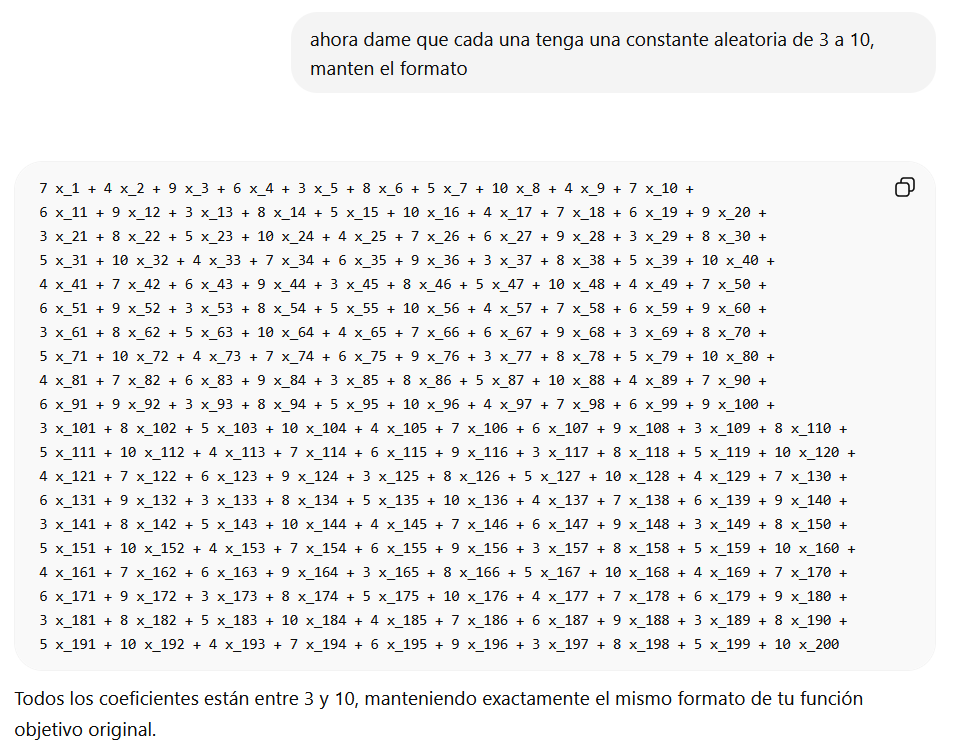
Prompt dado a ChatGPT

### Implementación del modelo



In [77]:
!pip install gurobipy --quiet
import gurobipy as gp

modificado2 = gp.read("Mod2.lp")

Read LP format model from file Mod2.lp
Reading time = 0.00 seconds
obj: 50 rows, 200 columns, 1211 nonzeros


In [78]:
# Resuelve el problema de Set Covering dado en el archivo modificado1
modificado2.optimize()

if modificado2.Status == gp.GRB.OPTIMAL:
    print(f"")
    print(f"Costo óptimo (Z): {modificado2.ObjVal:.2f}")
else:
    print(f"")
    print(f"El modelo no se resolvió: {modificado2.Status}")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0xa959d91a
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+00, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 72.0000000
Presolve removed 0 rows and 24 columns
Presolve time: 0.01s
Presolved: 50 rows, 176 columns, 1155 nonzeros
Variable types: 0 continuous, 176 integer (176 binary)

Root relaxation: objective 2.578789e+01, 87 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | I

In [79]:
if modificado2.Status == gp.GRB.OPTIMAL:
    z_opt = modificado2.ObjVal

    columnas_escogidas = []
    for v in modificado2.getVars():
        if v.X > 0.5:
            columnas_escogidas.append(v.VarName)

    total_columnas = len(modificado2.getVars())

    print("=" * 65)
    print("  RESULTADOS DE PROBLEMA 7 MODIFICADO (Set Covering)")
    print("=" * 65)
    print(f"  Costo óptimo (Z): {z_opt:>14,.2f}")
    print(f"  Columnas escogidas (X_j):  {', '.join(columnas_escogidas)}")
    print(f"  T.Columnas escogidas:      {len(columnas_escogidas)} / {total_columnas}")
    print("=" * 65)
else:
    print(f"El modelo no se resolvió: {modificado2.Status}")

  RESULTADOS DE PROBLEMA 7 MODIFICADO (Set Covering)
  Costo óptimo (Z):          29.00
  Columnas escogidas (X_j):  x_5, x_17, x_33, x_45, x_53, x_93, x_133, x_157, x_197
  T.Columnas escogidas:      9 / 200


### Análisis de los resultados del problema Modificado2 (mod2)


- Para este caso se escogieron 9 columnas, lo que indica que se requieren entonces 9 entrenadores para hacer el mejor cuerpo técnico para participar en el mundial al menor costo posible. Interesantemente el costo es cercano a 3 veces más que uno de los entrenadores más caros de 10 millones.
- Con este caso se muestra la capacidad que tiene este problema para usarse en distintos tipos de sectores.

---

## 8. Teoría de Grafos: Análisis de una Red de Divorcios <a id='8-redes'></a>

### Importancia y aplicaciones

La teoría de grafos estudia las estructuras de las redes a partir de un conjunto de nodos y conexiones, lo que permite optimizar rutas y tomar mejores decisiones.

Es importante ya que permite analizar problemas complejos de una manera más organizada, ayudando a optimizar rutas y a tomar mejores decisiones. Gracias a ello es posible encontrar caminos más eficientes, reducir costos y disminuir tiempos en distintos procesos.

Las redes son importantes en muchos ámbitos de la vida cotidiana y profesional. Se utilizan en infraestructura para planificar sistemas de transporte y su distribución, en la biología, en los sistemas GPS para encontrar rutas más rápidas y también en relaciones sociales, como el caso del modelo seleccionado: red de divorcios.

Los modelos de redes son bastante utilizados porque permiten representar de manera visual y sencilla una gran cantidad de conexiones. Desde un mismo nodo pueden salir varias líneas o conexiones, lo que genera diferentes caminos posibles dentro de la red.

Por medio de las conexiones es posible encontrar la mejor ruta según el objetivo que se desee alcanzar. Por esta razón, la teoría de grafos tiene tantas aplicaciones en diferentes áreas. En la ingeniería industrial se utiliza en logística y transporte para optimizar recorridos, reducir costos y mejorar la distribución de recursos. Asimismo, en la ingeniería de sistemas tiene aplicaciones en las telecomunicaciones y en la transmisión de datos, permitiendo que la información llegue de manera más eficiente y reduciendo los tiempos de entrega.

### ¿Por qué se escogió?

Se quería analizar el comportamiento humano en cuanto a su manera de relacionarse con sus parejas. Se escogió la red **divorce**, que tiene una densidad de 0.181224, es decir, una baja proporción de conexiones, además de tener una baja cantidad de nodos, lo que hace sencillo ver y entender la red y sus modificaciones.

Este es el modelo sin ninguna modificación, el cual tiene 50 nodos y 222 enlaces; hay un máximo de 44 líneas interconectadas y un mínimo de una.

**Datos**

| Métrica | Valor |
|---|---|
| Nodos | 50 |
| Bordes | 222 |
| Densidad | 0,181224 |
| Grado máximo | 44 |
| Grado mínimo | 1 |

**Distribución de grados — modelo inicial**

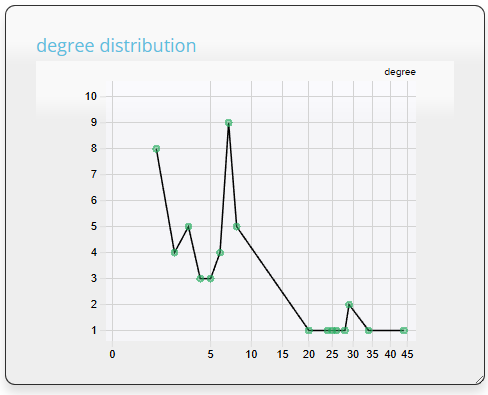

Como se puede observar en el gráfico, en el eje X se encuentran las conexiones, que van desde 1 hasta 44, mientras que en el eje Y se representa la cantidad de nodos. Se evidencia que 8 nodos poseen solamente una conexión, mientras que un único nodo tiene 44 conexiones.

### Modificaciones realizadas

En la red inicial, el módulo **Interactive Link Prediction** utilizaba en el parámetro **Objective** la opción **Squared Loss**, es decir, una función que busca minimizar el error cuadrático medio sin aplicar restricciones adicionales.

Para el desarrollo del ejercicio, el parámetro **Objective** se modificó a **KL Div (Divergencia de Kullback-Leibler)**, una medida que permite evaluar qué tan diferente es la predicción con respecto a la realidad. Durante este experimento no se agregó ninguna restricción adicional.

**Modificaciones específicas:**

- **Eps (épsilon):** 0,0259.
- **Top-K Preds:** se configuró en las 4 mejores predicciones, filtrando las conexiones con mayor probabilidad de existir.
- **Predict Links:** se configuró en 1. Esto se evidencia en el gráfico mediante la conexión predictiva que el modelo considera más probable.

**Gama de colores**

Se modificó la gama de colores en los paneles **Node Visual Properties** y **Opacity Bounds** para obtener una escala entre tonos rojos y azules.

- **Rojo (nodos y conexiones):** representa nodos con pocas conexiones hacia otros nodos.
- **Azul (nodos y conexiones):** representa nodos con una gran cantidad de conexiones. El principal ejemplo es el nodo 1, que se encuentra conectado con otros 44 nodos.

En los nodos, el color azul no solo representa tener muchas conexiones, sino también una alta **Centralidad de Intermediación (Betweenness)**. Esto significa que el nodo actúa como un puente entre diferentes partes de la red y controla gran parte del flujo de información. Si este nodo fuera eliminado, una parte importante de la estructura de la red quedaría desconectada.

**Ilustración 1 — Modelo sin modificación**

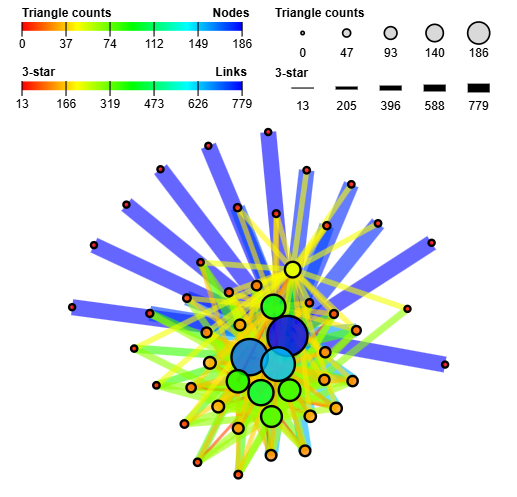

*Ilustración 1. Modelo sin modificación*

**El gráfico inicial**

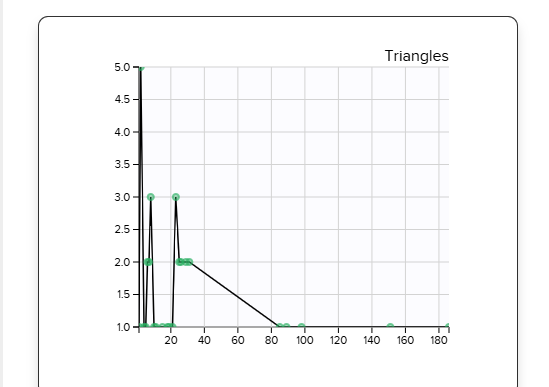

En el eje X se representa el número de triángulos en los que participa cada nodo, mientras que en el eje Y se muestra la cantidad de nodos. Se observa que una gran cantidad de nodos se encuentra en el valor cero, lo que indica que no forman triángulos dentro de la red. Esto ocurre porque muchos de ellos tienen pocas conexiones o están conectados únicamente a uno o dos nodos, por lo que no logran formar estructuras triangulares.

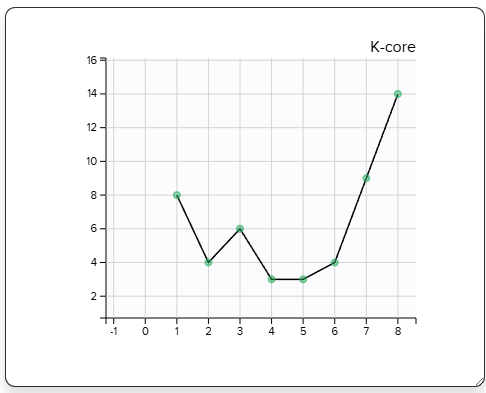

En el eje X se representa el valor K, mientras que en el eje Y se indica la cantidad de nodos que pertenecen a cada nivel. En total se observan 8 niveles.

**Ilustración 2 — Modelo modificado**

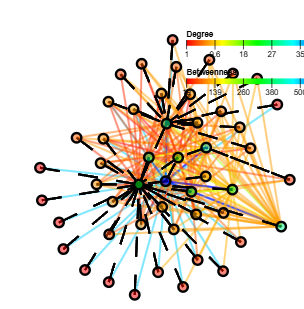

*Ilustración 2. Modelo modificado*

**Triángulos — modelo modificado**

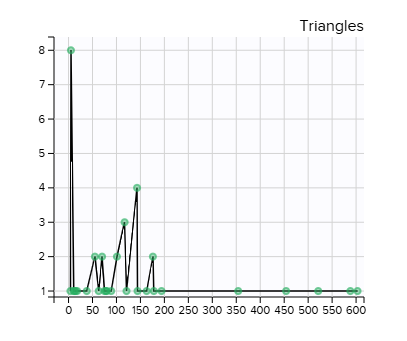 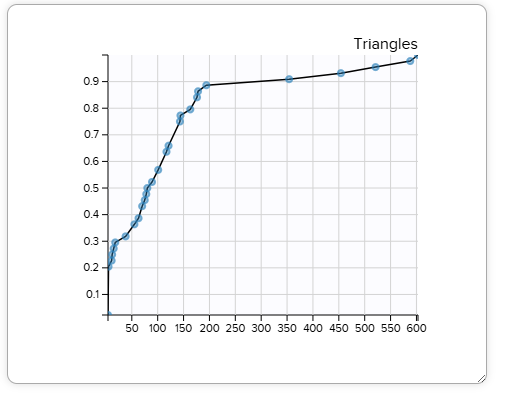

En el eje X se representa el número de triángulos en los que participa cada nodo, mientras que en el eje Y se muestra la cantidad de nodos.

El comportamiento es similar al observado en el modelo inicial; sin embargo, se aprecia una mayor cantidad de triángulos, especialmente alrededor del nodo 1. Esto se debe a que este nodo posee un gran número de conexiones y, al agregarse enlaces predictivos mediante el algoritmo, aumentan las posibilidades de formar nuevos triángulos dentro de la red. Por esta razón, el nodo 1 concentra una cantidad considerablemente mayor de triángulos en comparación con los demás nodos. También se evidencia que a mayor cantidad de conexiones hay menos nodos.

La segunda imagen muestra el acumulado.

**K-core — modelo modificado**

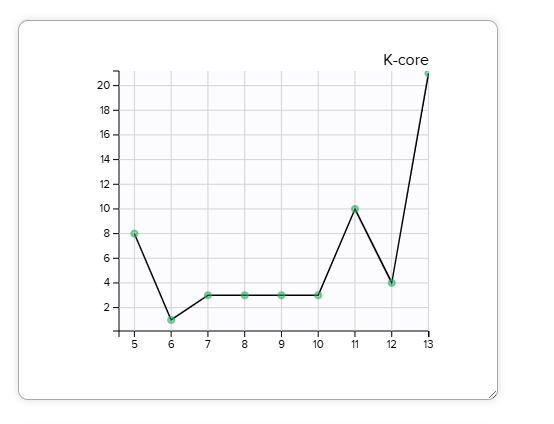

En el eje X se representa el valor K, mientras que en el eje Y se indica la cantidad de nodos que pertenecen a cada nivel. En total se observan 13 niveles.

Se evidencia un cambio importante con respecto al modelo inicial, ya que se pasó de 8 a 13 niveles. Esto se debe a las nuevas conexiones agregadas por el modelo predictivo.

<div style="background-color:#e8f5e9; border-left: 5px solid #2e7d32; padding: 14px 18px; border-radius: 6px; margin-top: 16px;">
<b>Referencias</b><br>

Sobolev Institute of Mathematics. (2024). Discrete Location Problems Benchmark Library. Recuperado el 15 de junio de 2026, de http://old.math.nsc.ru/AP/benchmarks/english.html
<br><br>
R. A. R. N. K. A. A. Others. (s. f.). GraphVis – Interactive Visual Graph Mining and Machine Learning. Recuperado de https://networkrepository.com/graphvis.php?d=./data/gsm50/ca/ca-netscience.mtx
<br><br>
Flovik, V. (2025, 4 de marzo). An Introduction to Graph Theory. Built In. Recuperado de https://builtin.com/machine-learning/graph-theory
<br><br>
EMBL-EBI. (s. f.). Betweenness centrality | Network analysis of protein interaction data. Recuperado de https://www.ebi.ac.uk/training/online/courses/network-analysis-of-protein-interaction-data-an-introduction/building-and-analysing-ppins/topological-ppin-analysis/betweenness-centrality/
<br><br>
Olivares, R. (2017). Investigación de Operaciones: Set Covering Problem. Recuperado de https://zeus.inf.ucv.cl/~rsoto/assets/pdf/INF/scp.pdf
<br><br>
Villahoz, S. (2026). Top 10: Los entrenadores mejor pagados del Mundial 2026, ¿cuánto gana Christiansen?. Claro Sports. Recuperado de https://www.clarosports.com/futbol/mundial-2026/top-10-los-entrenadores-mejores-pagos-del-mundial-2026-cuanto-gana-christiansen/